In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

sc.logging.print_header()

/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.v

Package,Version
numpy,2.3.5
pandas,2.3.3
matplotlib,3.10.7
seaborn,0.13.2
scanpy,1.11.5
squidpy,1.6.5
Component,Info
Python,"3.11.13 (main, Sep 2 2025, 14:20:25) [Clang 20.1.4 ]"
OS,Linux-5.15.0-124-generic-x86_64-with-glibc2.35
CPU,"96 logical CPU cores, x86_64"


In [5]:
vizgen_dir ="./Vizgen"

adata = sq.read.vizgen(
    path=vizgen_dir,
    counts_file="datasets_mouse_brain_map_BrainReceptorShowcase_Slice1_Replicate1_cell_by_gene_S1R1.csv",
    meta_file="datasets_mouse_brain_map_BrainReceptorShowcase_Slice1_Replicate1_cell_metadata_S1R1.csv",
    transformation_file="datasets_mouse_brain_map_BrainReceptorShowcase_Slice1_Replicate1_images_micron_to_mosaic_pixel_transform.csv",
)

Calculate quality control metrics

In [6]:
sc.pp.calculate_qc_metrics(adata, percent_top=(50, 100, 200, 300), inplace=True)

In [7]:
adata.obsm["blank_genes"].to_numpy().sum() / adata.var["total_counts"].sum() * 100

np.float32(0.38927388)

<Axes: title={'center': 'Volume of segmented cells'}, xlabel='volume', ylabel='Count'>

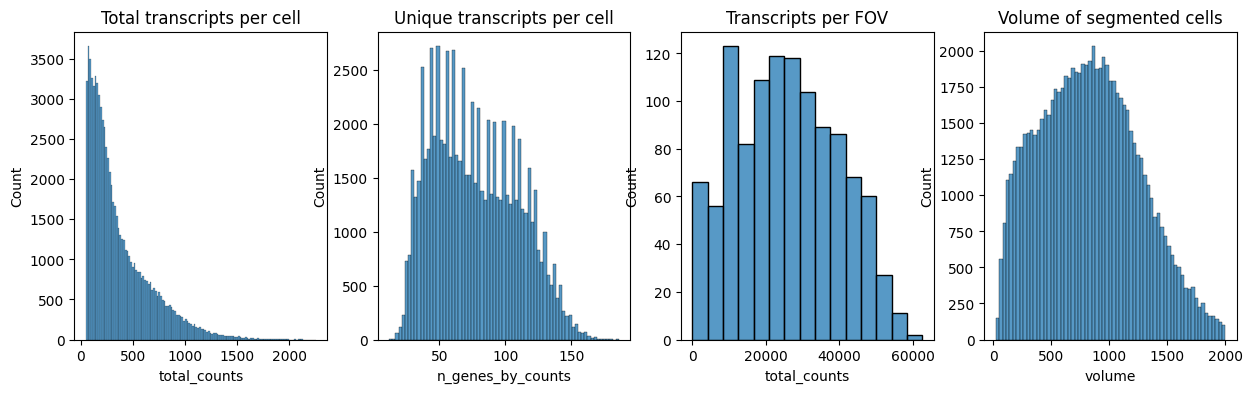

In [8]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))

axs[0].set_title("Total transcripts per cell")
sns.histplot(
    adata.obs["total_counts"],
    kde=False,
    ax=axs[0],
)

axs[1].set_title("Unique transcripts per cell")
sns.histplot(
    adata.obs["n_genes_by_counts"],
    kde=False,
    ax=axs[1],
)

axs[2].set_title("Transcripts per FOV")
sns.histplot(
    adata.obs.groupby("fov").sum()["total_counts"],
    kde=False,
    ax=axs[2],
)

axs[3].set_title("Volume of segmented cells")
sns.histplot(
    adata.obs["volume"],
    kde=False,
    ax=axs[3],
)

In [9]:
sc.pp.filter_cells(adata, min_counts=10)

In [10]:
adata.layers["counts"] = adata.X.copy()
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=4000)
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)

/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_3852072/1626904081.py:8: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


Visualize annotation on UMAP and spatial coordinates

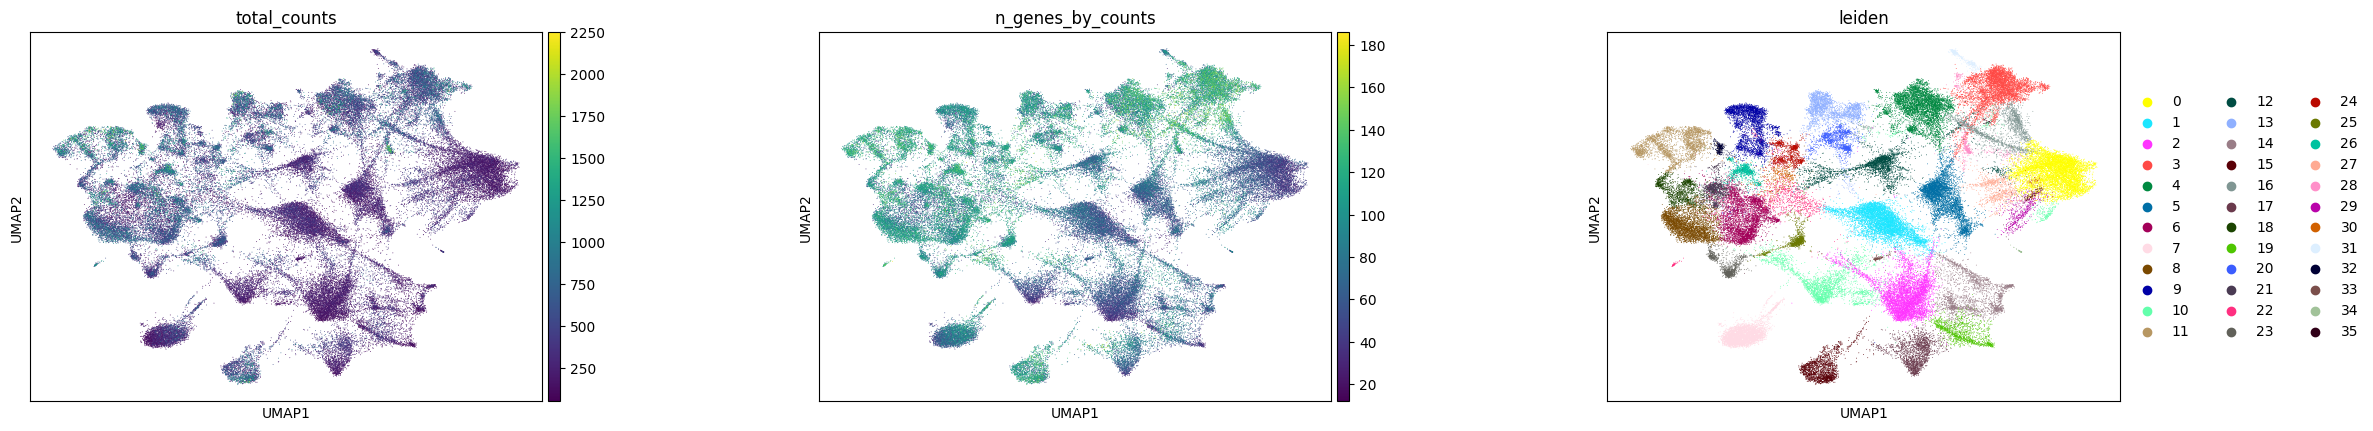

In [11]:
sc.pl.umap(
    adata,
    color=[
        "total_counts",
        "n_genes_by_counts",
        "leiden",
    ],
    wspace=0.4,
)

/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


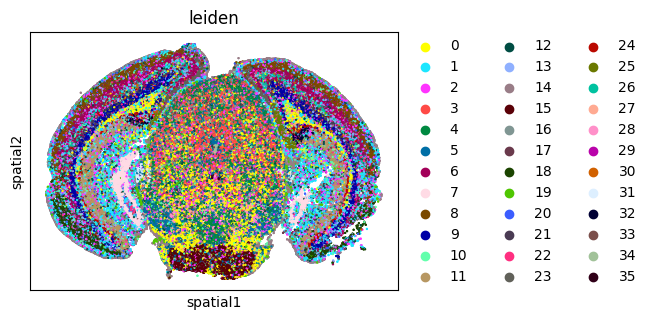

In [12]:
sq.pl.spatial_scatter(
    adata,
    shape=None,
    color=[
        "leiden",
    ],
    wspace=0.4,
)

Computation of spatial statistics

Building the spatial neighbors graphs

In [14]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

Compute centrality scores

In [15]:
sq.gr.centrality_scores(adata, cluster_key="leiden")

/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


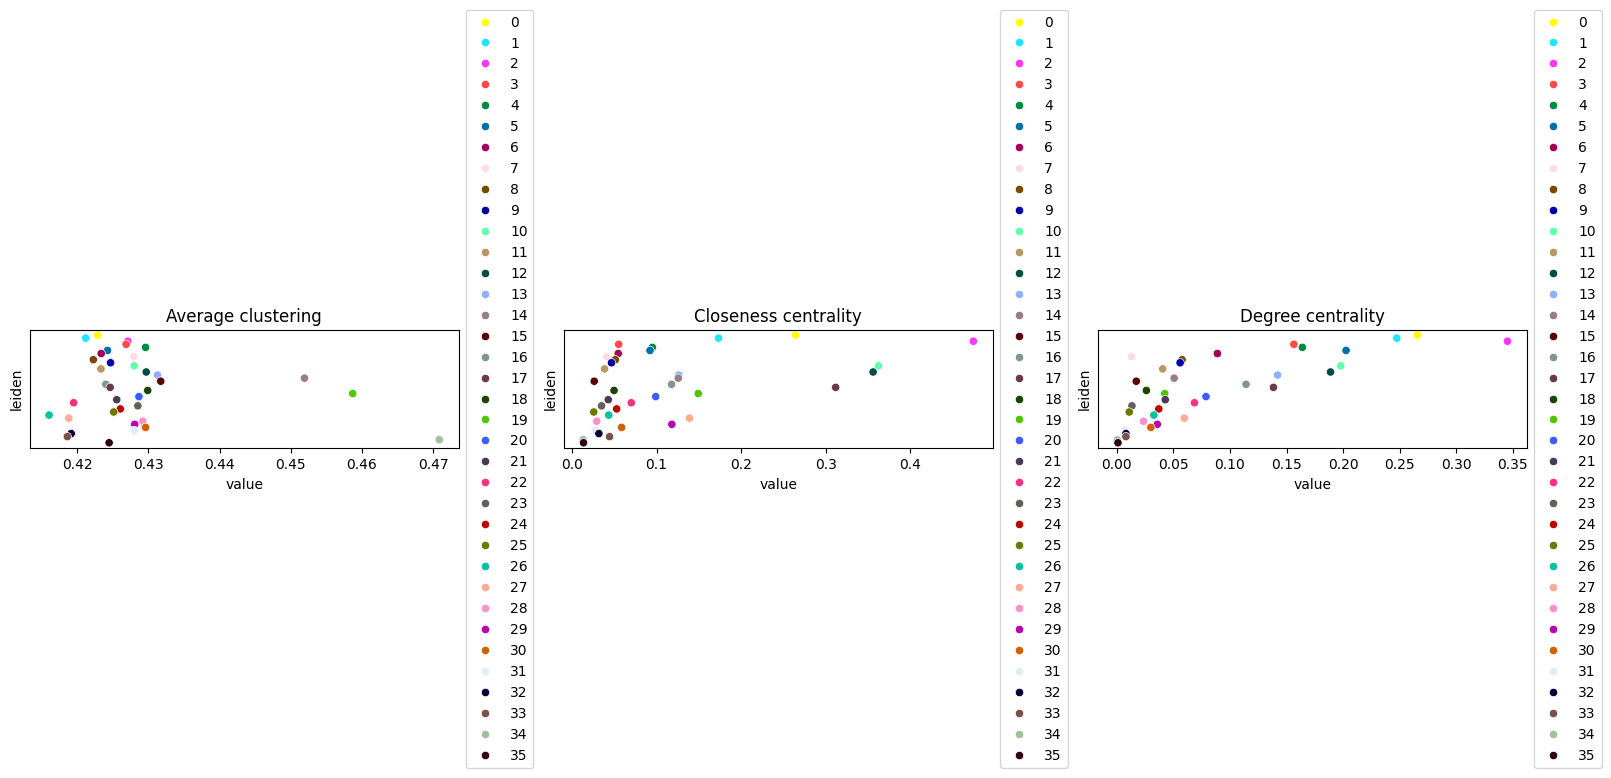

In [16]:
sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(16, 5))

Compute co-occurrence probability

In [17]:
adata_subsample = sc.pp.subsample(adata, fraction=0.5, copy=True)

100%|██████████| 210/210 [02:50<00:00,  1.23/s]


/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


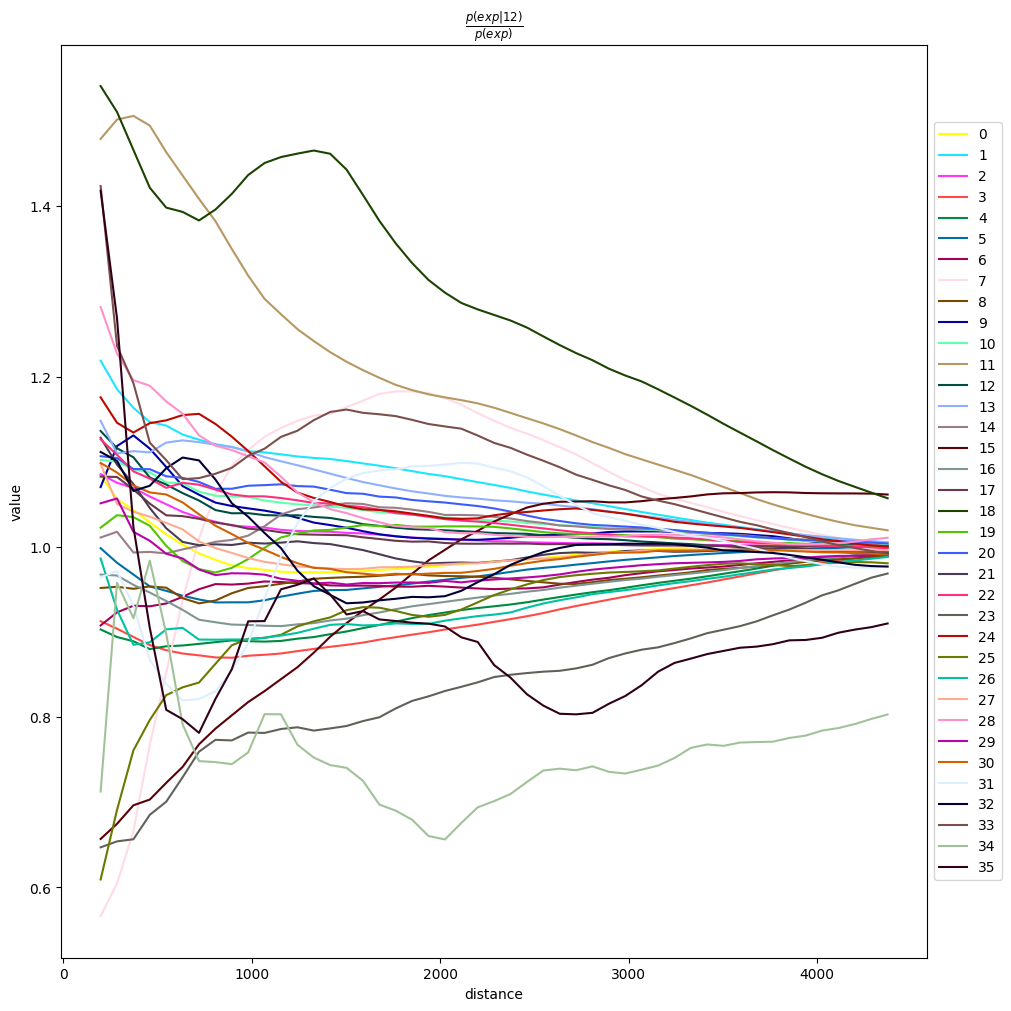

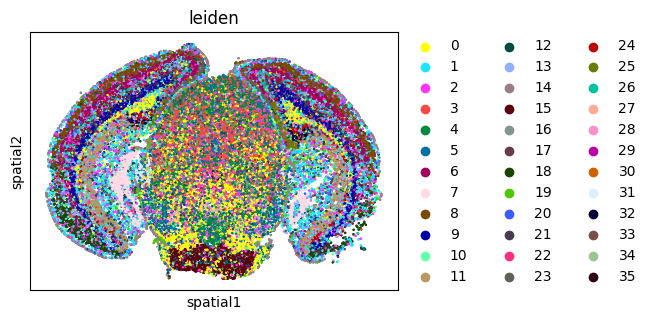

In [18]:
sq.gr.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
)
sq.pl.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
    clusters="12",
    figsize=(10, 10),
)
sq.pl.spatial_scatter(
    adata_subsample,
    color="leiden",
    shape=None,
    size=2,
)

Neighbors enrichment analysis

In [19]:
sq.gr.nhood_enrichment(adata, cluster_key="leiden")

100%|██████████| 1000/1000 [00:06<00:00, 158.20/s]


/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


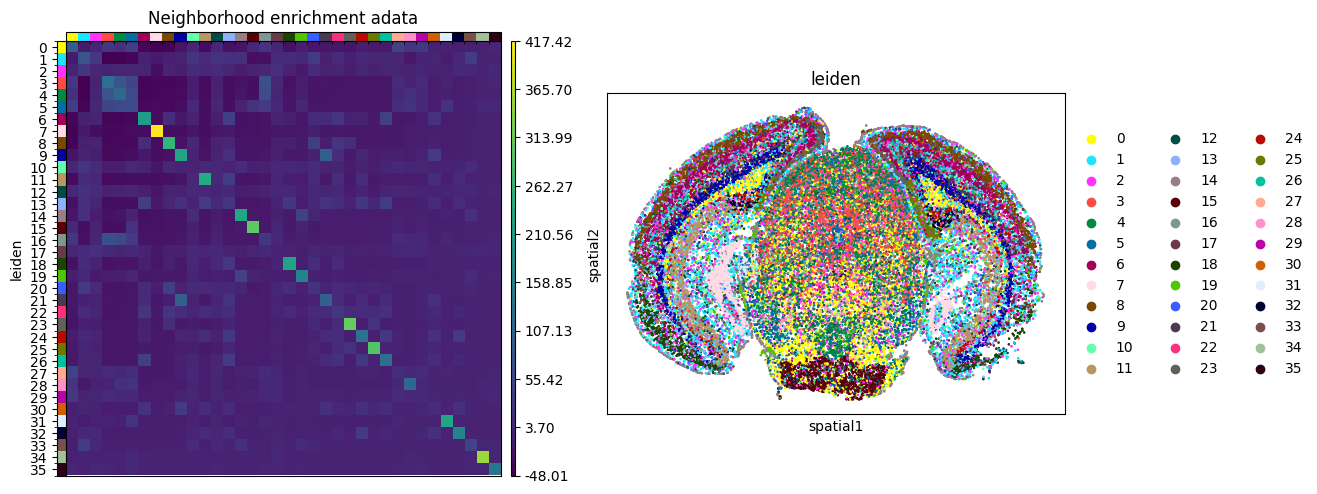

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden",
    figsize=(8, 8),
    title="Neighborhood enrichment adata",
    ax=ax[0],
)
sq.pl.spatial_scatter(adata_subsample, color="leiden", shape=None, size=2, ax=ax[1])

Compute Ripley’s statistics

/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


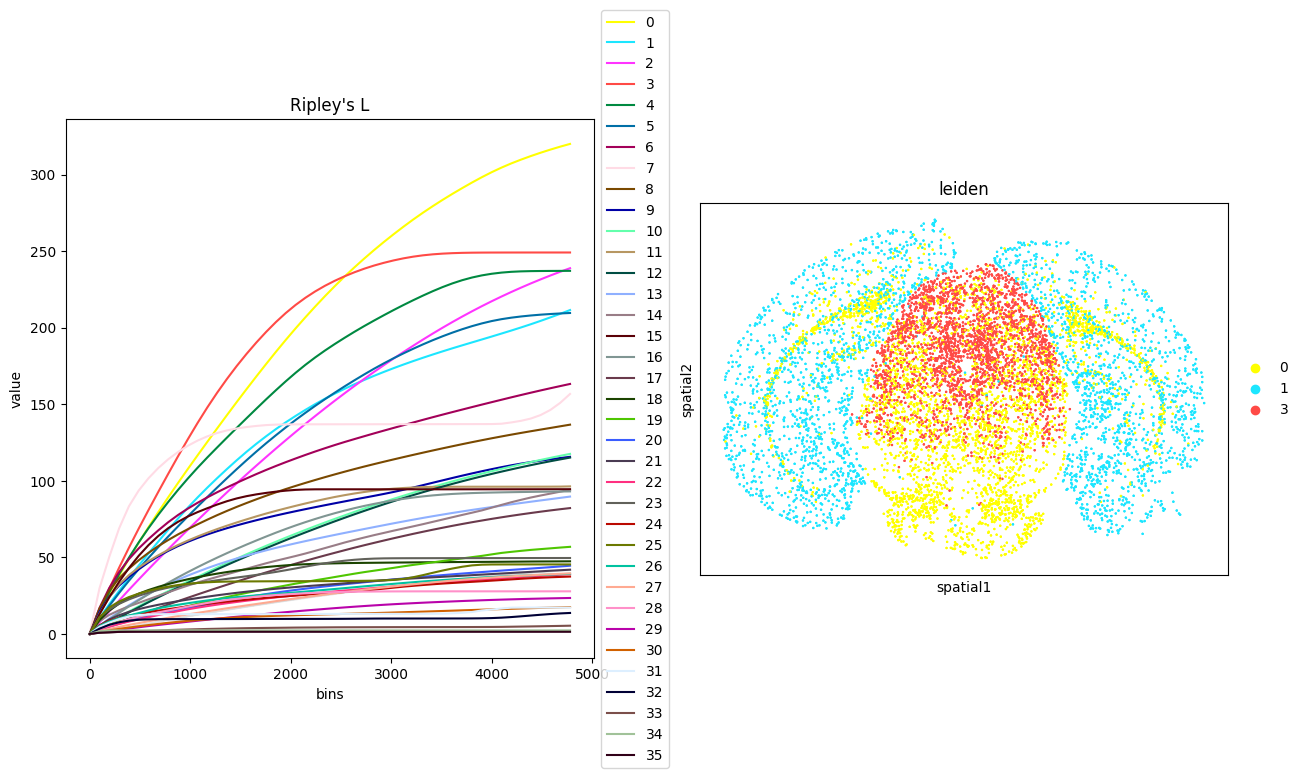

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
mode = "L"

sq.gr.ripley(adata, cluster_key="leiden", mode=mode)
sq.pl.ripley(adata, cluster_key="leiden", mode=mode, ax=ax[0])

sq.pl.spatial_scatter(
    adata_subsample,
    color="leiden",
    groups=["0", "1", "3"],
    shape=None,
    size=2,
    ax=ax[1],
)

Compute Moran’s I score

In [22]:
sq.gr.spatial_neighbors(adata_subsample, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata_subsample,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)
adata_subsample.uns["moranI"].head(10)

100%|██████████| 100/100 [00:16<00:00,  6.00/s]


,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
Slc17a7,0.699380,0.0,0.000009,0.0,0.009901,0.000023,0.0,0.0,0.012294
Chrm1,0.577472,0.0,0.000009,0.0,0.009901,0.000019,0.0,0.0,0.012294
Gfap,0.573752,0.0,0.000009,0.0,0.009901,0.000018,0.0,0.0,0.012294
Baiap2,0.460600,0.0,0.000009,0.0,0.009901,0.000016,0.0,0.0,0.012294
Mas1,0.415356,0.0,0.000009,0.0,0.009901,0.000013,0.0,0.0,0.012294
Grin2b,0.411849,0.0,0.000009,0.0,0.009901,0.000013,0.0,0.0,0.012294
Sstr4,0.401322,0.0,0.000009,0.0,0.009901,0.000016,0.0,0.0,0.012294
Glp2r,0.393550,0.0,0.000009,0.0,0.009901,0.000016,0.0,0.0,0.012294
Npy2r,0.377881,0.0,0.000009,0.0,0.009901,0.000011,0.0,0.0,0.012294
Gprc5b,0.375281,0.0,0.000009,0.0,0.009901,0.000015,0.0,0.0,0.012294


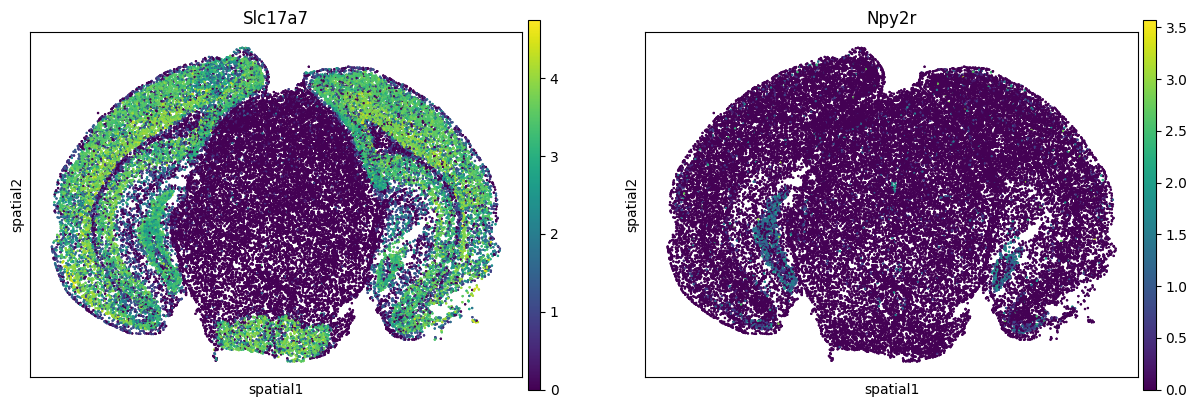

In [23]:
sq.pl.spatial_scatter(
    adata_subsample,
    color=[
        "Slc17a7",
        "Npy2r",
    ],
    shape=None,
    size=2,
    img=False,
)